# Bellabeat Case Study: Smart Device Usage Analysis

This notebook analyzes Fitbit smart device data to identify patterns in activity, sleep, and sedentary behavior.

The project follows the data analysis process: Ask, Prepare, Process, Analyze, Share, and Act.

# Ask Phase

## Business Task

Bellabeat wants to understand how smart device users track activity and sleep.

The goal of this analysis is to identify wellness patterns and provide business recommendations for Bellabeat.

# Prepare Phase

## Data Source

This analysis uses Fitbit smart device data.

The datasets include daily activity records and sleep records.

The data will be cleaned and prepared before analysis.

In [127]:
from pathlib import Path

BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

RAW_DIR = BASE_DIR / "data" / "raw"
CLEAN_DIR = BASE_DIR / "data" / "clean"

print("Base folder:", BASE_DIR)
print("Raw folder:", RAW_DIR)
print("Clean folder:", CLEAN_DIR)
print("Raw folder exists:", RAW_DIR.exists())

Base folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study
Raw folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/data/raw
Clean folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/data/clean
Raw folder exists: True


In [128]:
print("Files in raw folder:")

for file in RAW_DIR.iterdir():
    print(file.name)

Files in raw folder:
dailyActivity_merged.csv
sleepDay_merged.csv
.ipynb_checkpoints


In [129]:
import pandas as pd

daily = pd.read_csv(RAW_DIR / "dailyActivity_merged.csv")
sleep = pd.read_csv(RAW_DIR / "sleepDay_merged.csv")

print("Files loaded successfully.")

Files loaded successfully.


In [130]:
daily.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [131]:
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [132]:
from pathlib import Path

In [133]:
BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

In [134]:
RAW_DIR = BASE_DIR / "data" / "raw"
CLEAN_DIR = BASE_DIR / "data" / "clean"

In [135]:
print("Base folder:", BASE_DIR)
print("Raw folder:", RAW_DIR)
print("Clean folder:", CLEAN_DIR)
print("Raw folder exists:", RAW_DIR.exists())

Base folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study
Raw folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/data/raw
Clean folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/data/clean
Raw folder exists: True


In [136]:
print("Daily rows and columns:" , daily.shape)
print("Sleep rows and columns:" , sleep.shape)

Daily rows and columns: (940, 15)
Sleep rows and columns: (413, 5)


## Initial Data Check

The daily activity dataset contains 940 rows and 15 columns.

The sleep dataset contains 413 rows and 5 columns.

Both datasets loaded correctly and are ready for the next processing checks.

In [137]:
daily.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='str')

In [138]:
sleep.columns

Index(['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep',
       'TotalTimeInBed'],
      dtype='str')

In [139]:
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    str    
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories             

In [140]:
sleep.info()

<class 'pandas.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Id                  413 non-null    int64
 1   SleepDay            413 non-null    str  
 2   TotalSleepRecords   413 non-null    int64
 3   TotalMinutesAsleep  413 non-null    int64
 4   TotalTimeInBed      413 non-null    int64
dtypes: int64(4), str(1)
memory usage: 16.3 KB


In [141]:
daily.duplicated().sum()

np.int64(0)

In [142]:
sleep.duplicated().sum()

np.int64(3)

In [143]:
sleep[sleep.duplicated(keep=False)]

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
160,4388161847,5/5/2016 12:00:00 AM,1,471,495
161,4388161847,5/5/2016 12:00:00 AM,1,471,495
222,4702921684,5/7/2016 12:00:00 AM,1,520,543
223,4702921684,5/7/2016 12:00:00 AM,1,520,543
379,8378563200,4/25/2016 12:00:00 AM,1,388,402
380,8378563200,4/25/2016 12:00:00 AM,1,388,402


The daily activity dataset does not contain duplicate rows.

The sleep dataset contains 3 duplicate rows. After reviewing them, I confirmed that they are exact duplicate records.

In [144]:
sleep_before = sleep.shape[0]

In [145]:
sleep= sleep.drop_duplicates()

In [146]:
sleep_after = sleep.shape[0]

In [147]:
print("Rows before:", sleep_before)

Rows before: 413


In [148]:
print("Rows after:", sleep_after)

Rows after: 410


In [149]:
print("Rows removed:", sleep_before -sleep_after)

Rows removed: 3


In [150]:
print("Sleep duplicates after cleaning:", sleep.duplicated().sum())

Sleep duplicates after cleaning: 0


I removed 3 duplicate rows from the sleep dataset.

The sleep dataset decreased from 413 rows to 410 rows.

After cleaning, the sleep dataset no longer contains duplicate records.

## Check Missing Values

In this step, I check if the datasets contain missing values.

Missing values can affect the analysis because some calculations may be incomplete or inaccurate.

In [151]:
daily.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [152]:
sleep.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

No missing values were found in the daily activity dataset or the sleep dataset.

In [153]:
daily_missing_rows = daily[daily.isnull().any(axis=1)]
sleep_missing_rows = sleep[sleep.isnull().any(axis=1)]

print("Daily rows with missing values:", daily_missing_rows.shape[0])
print("Sleep rows with missing values:", sleep_missing_rows.shape[0])

Daily rows with missing values: 0
Sleep rows with missing values: 0


I checked missing values by column and by row. This helped me confirm whether the datasets had incomplete records before analysis.

## Clean Column Names

In this step, I clean the column names to make them easier to use in Python.

I convert the column names to lowercase and separate words with underscores.

In [154]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
    df.columns
      .str.strip()
      .str.replace(" " , "_")
      .str.replace(r"(?<!^)(?=[A-Z])", "_", regex=True)
      .str.lower()           
                  
)
    return df

In [155]:
daily_test = clean_column_names(daily)
daily_test = clean_column_names(sleep)

In [156]:
daily = clean_column_names(daily)
sleep = clean_column_names(sleep)

## Convert Date Columns

In this step, I convert the date columns from text format to datetime format.

This is important because dates are needed to analyze records over time and to connect activity and sleep data by user and date.

In [157]:
daily.columns

Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories'],
      dtype='str')

In [158]:
sleep.columns

Index(['id', 'sleep_day', 'total_sleep_records', 'total_minutes_asleep',
       'total_time_in_bed'],
      dtype='str')

In [159]:
daily["activity_date"]= pd.to_datetime(
    daily["activity_date"],
    format = "%m/%d/%Y"

)
sleep["sleep_day"]= pd.to_datetime(
    sleep["sleep_day"],
    format= "%m/%d/%Y %I:%M:%S %p"

)

In [160]:
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          940 non-null    int64         
 1   activity_date               940 non-null    datetime64[us]
 2   total_steps                 940 non-null    int64         
 3   total_distance              940 non-null    float64       
 4   tracker_distance            940 non-null    float64       
 5   logged_activities_distance  940 non-null    float64       
 6   very_active_distance        940 non-null    float64       
 7   moderately_active_distance  940 non-null    float64       
 8   light_active_distance       940 non-null    float64       
 9   sedentary_active_distance   940 non-null    float64       
 10  very_active_minutes         940 non-null    int64         
 11  fairly_active_minutes       940 non-null    int64         
 12  light

In [161]:
sleep.info()

<class 'pandas.DataFrame'>
Index: 410 entries, 0 to 412
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    410 non-null    int64         
 1   sleep_day             410 non-null    datetime64[us]
 2   total_sleep_records   410 non-null    int64         
 3   total_minutes_asleep  410 non-null    int64         
 4   total_time_in_bed     410 non-null    int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 19.2 KB


In [162]:
daily.head()

,id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [163]:
sleep.head()

,id,sleep_day,total_sleep_records,total_minutes_asleep,total_time_in_bed
0,1503960366,2016-04-12,1,327,346
1,1503960366,2016-04-13,2,384,407
2,1503960366,2016-04-15,1,412,442
3,1503960366,2016-04-16,2,340,367
4,1503960366,2016-04-17,1,700,712


## Create Date Column

I create a new date column in both datasets.

This will help me join activity and sleep records by user and date later in the analysis.

In [164]:
daily["date"] = daily["activity_date"].dt.date
sleep["date"] = sleep["sleep_day"].dt.date

In [165]:
daily[["id", "activity_date", "date"]].head()

,id,activity_date,date
0,1503960366,2016-04-12,2016-04-12
1,1503960366,2016-04-13,2016-04-13
2,1503960366,2016-04-14,2016-04-14
3,1503960366,2016-04-15,2016-04-15
4,1503960366,2016-04-16,2016-04-16


In [166]:
sleep[["id", "sleep_day", "date"]].head()

,id,sleep_day,date
0,1503960366,2016-04-12,2016-04-12
1,1503960366,2016-04-13,2016-04-13
2,1503960366,2016-04-15,2016-04-15
3,1503960366,2016-04-16,2016-04-16
4,1503960366,2016-04-17,2016-04-17


The date column was created in both datasets.

This gives both tables the same date field, which will make it easier to join activity and sleep data by user and date during the analysis phase.

## Create Total Active Minutes

I create a new column called total_active_minutes.

This column combines very active, fairly active, and lightly active minutes into one total activity measure.

In [167]:
daily["total_active_minutes"] = (
    daily["very_active_minutes"]
    + daily["fairly_active_minutes"]
    + daily["lightly_active_minutes"]
)

In [168]:
daily[[
    "id",
    "date",
    "very_active_minutes",
    "fairly_active_minutes",
    "lightly_active_minutes",
    "total_active_minutes"
]].head()

,id,date,very_active_minutes,fairly_active_minutes,lightly_active_minutes,total_active_minutes
0,1503960366,2016-04-12,25,13,328,366
1,1503960366,2016-04-13,21,19,217,257
2,1503960366,2016-04-14,30,11,181,222
3,1503960366,2016-04-15,29,34,209,272
4,1503960366,2016-04-16,36,10,221,267


## Create Activity Level

I create an activity_level column based on total daily steps.

This will help classify each day as Low, Medium, or High activity.

In [169]:
def activity_level(steps):
    if steps < 5000:
        return "Low"
    elif steps < 10000:
        return "Medium"
    else:
        return "High"

In [170]:
daily["activity_level"] = daily["total_steps"].apply(activity_level)

In [171]:
daily[[
    "id",
    "date",
    "total_steps",
    "activity_level"
]].head(10)

,id,date,total_steps,activity_level
0,1503960366,2016-04-12,13162,High
1,1503960366,2016-04-13,10735,High
2,1503960366,2016-04-14,10460,High
3,1503960366,2016-04-15,9762,Medium
4,1503960366,2016-04-16,12669,High
5,1503960366,2016-04-17,9705,Medium
6,1503960366,2016-04-18,13019,High
7,1503960366,2016-04-19,15506,High
8,1503960366,2016-04-20,10544,High
9,1503960366,2016-04-21,9819,Medium


In [172]:
daily["activity_level"].value_counts()

activity_level
Medium    334
High      303
Low       303
Name: count, dtype: int64

I created total_active_minutes to combine all active minutes into one column.

I also created activity_level to classify daily step counts as Low, Medium, or High activity.

These new columns will help analyze activity patterns more clearly.

In [173]:
daily.head()

,id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,date,total_active_minutes,activity_level
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,366,High
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13,257,High
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,2016-04-14,222,High
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15,272,Medium
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16,267,High


## Create Sleep Columns

I create new sleep columns to make the sleep data easier to analyze.

The original sleep values are in minutes, so I convert them to hours and calculate the time spent in bed while awake.

In [174]:
sleep["sleep_hours"] = sleep["total_minutes_asleep"] / 60

In [175]:
sleep["time_in_bed_hours"] = sleep["total_time_in_bed"] / 60

In [176]:
sleep["awake_time_in_bed_minutes"] = (
    sleep["total_time_in_bed"] - sleep["total_minutes_asleep"]
)

In [177]:
sleep[[
    "id",
    "date",
    "total_minutes_asleep",
    "total_time_in_bed",
    "sleep_hours",
    "time_in_bed_hours",
    "awake_time_in_bed_minutes"
]].head()

,id,date,total_minutes_asleep,total_time_in_bed,sleep_hours,time_in_bed_hours,awake_time_in_bed_minutes
0,1503960366,2016-04-12,327,346,5.450000,5.766667,19
1,1503960366,2016-04-13,384,407,6.400000,6.783333,23
2,1503960366,2016-04-15,412,442,6.866667,7.366667,30
3,1503960366,2016-04-16,340,367,5.666667,6.116667,27
4,1503960366,2016-04-17,700,712,11.666667,11.866667,12


In [178]:
sleep["sleep_hours"] = (sleep["total_minutes_asleep"] / 60).round(2)
sleep["time_in_bed_hours"] = (sleep["total_time_in_bed"] / 60).round(2)

In [179]:
sleep.head()

,id,sleep_day,total_sleep_records,total_minutes_asleep,total_time_in_bed,date,sleep_hours,time_in_bed_hours,awake_time_in_bed_minutes
0,1503960366,2016-04-12,1,327,346,2016-04-12,5.45,5.77,19
1,1503960366,2016-04-13,2,384,407,2016-04-13,6.40,6.78,23
2,1503960366,2016-04-15,1,412,442,2016-04-15,6.87,7.37,30
3,1503960366,2016-04-16,2,340,367,2016-04-16,5.67,6.12,27
4,1503960366,2016-04-17,1,700,712,2016-04-17,11.67,11.87,12


I converted sleep minutes and time in bed minutes into hours to make the values easier to understand. I also calculated awake_time_in_bed_minutes as the difference between time in bed and time asleep.

In [180]:
print("Daily shape:", daily.shape)
print("Sleep shape:", sleep.shape)

Daily shape: (940, 18)
Sleep shape: (410, 9)


In [181]:
print("Daily duplicates:", daily.duplicated().sum())
print("Sleep duplicates:", sleep.duplicated().sum())

Daily duplicates: 0
Sleep duplicates: 0


In [182]:
print("Daily missing values:")
print(daily.isnull().sum())

print("\nSleep missing values:")
print(sleep.isnull().sum())

Daily missing values:
id                            0
activity_date                 0
total_steps                   0
total_distance                0
tracker_distance              0
logged_activities_distance    0
very_active_distance          0
moderately_active_distance    0
light_active_distance         0
sedentary_active_distance     0
very_active_minutes           0
fairly_active_minutes         0
lightly_active_minutes        0
sedentary_minutes             0
calories                      0
date                          0
total_active_minutes          0
activity_level                0
dtype: int64

Sleep missing values:
id                           0
sleep_day                    0
total_sleep_records          0
total_minutes_asleep         0
total_time_in_bed            0
date                         0
sleep_hours                  0
time_in_bed_hours            0
awake_time_in_bed_minutes    0
dtype: int64


In [183]:
daily.columns

Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories', 'date',
       'total_active_minutes', 'activity_level'],
      dtype='str')

In [184]:
sleep.columns

Index(['id', 'sleep_day', 'total_sleep_records', 'total_minutes_asleep',
       'total_time_in_bed', 'date', 'sleep_hours', 'time_in_bed_hours',
       'awake_time_in_bed_minutes'],
      dtype='str')

In [185]:
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

In [186]:
daily.to_csv(CLEAN_DIR / "daily_activity_clean.csv", index=False)
sleep.to_csv(CLEAN_DIR / "sleep_clean.csv", index=False)

print("Clean files saved successfully.")

Clean files saved successfully.


In [187]:
for file in CLEAN_DIR.iterdir():
    print(file.name)

sleep_clean.csv
daily_activity_clean.csv
.ipynb_checkpoints


## Process Summary

In this phase, I cleaned and prepared the Fitbit activity and sleep datasets for analysis.

The main steps were:

- Loaded the raw CSV files
- Checked rows and columns
- Reviewed column names and data types
- Checked duplicate records
- Removed 3 duplicate rows from the sleep dataset
- Checked missing values by column and by row
- Cleaned column names
- Converted date columns to datetime format
- Created a common date column
- Created new calculated columns
- Exported clean CSV files

The cleaned datasets are ready for the analysis phase.

# Analyze Phase

In this phase, I analyze the cleaned Fitbit activity and sleep datasets.

The goal is to identify trends in activity, sedentary behavior, calories, and sleep patterns.

In [188]:
daily_clean = pd.read_csv(CLEAN_DIR / "daily_activity_clean.csv")
sleep_clean = pd.read_csv(CLEAN_DIR / "sleep_clean.csv")

In [189]:
import sqlite3

In [190]:
conn = sqlite3.connect("bellabeat.db")

In [191]:
daily_clean.to_sql("daily_activity", conn, if_exists="replace", index=False)
sleep_clean.to_sql("sleep", conn, if_exists="replace", index=False)

410

In [192]:
query = """
SELECT COUNT(DISTINCT id) AS total_users
FROM daily_activity;
"""

pd.read_sql_query(query, conn)

,total_users
0,33


In [193]:
query = """
SELECT COUNT(*) AS total_daily_records
FROM daily_activity;
"""

pd.read_sql_query(query, conn)

,total_daily_records
0,940


In [194]:
query = """
SELECT COUNT(*) AS total_sleep_records
FROM sleep;
"""

pd.read_sql_query(query, conn)

,total_sleep_records
0,410


In [195]:
query = """
SELECT COUNT(DISTINCT id) AS total_sleep_users
FROM sleep;
"""

pd.read_sql_query(query, conn)

,total_sleep_users
0,24


The daily activity dataset contains 33 users, while the sleep dataset contains 24 users.

In [196]:
query = """
SELECT
    MIN(date) AS start_date,
    MAX(date) AS end_date
FROM daily_activity;
"""

pd.read_sql_query(query, conn)

,start_date,end_date
0,2016-04-12,2016-05-12


## Activity Summary

I calculate average steps, calories, sedentary minutes, and active minutes to understand general activity patterns.

In [197]:
query = """
Select
    ROUND (AVG(total_steps) , 2) as Avg_total_steps,
    ROUND (AVG(calories), 2) as Avg_calories,
    ROUND(AVG(sedentary_minutes), 2) as Avg_sedentary_minutes,
    ROUND(AVG(total_active_minutes), 2) as Avg_total_active_minutes
From daily_activity;
"""

pd.read_sql_query(query, conn)

,Avg_total_steps,Avg_calories,Avg_sedentary_minutes,Avg_total_active_minutes
0,7637.91,2303.61,991.21,227.54


## Activity Level Distribution

I analyze how many daily records are classified as Low, Medium, or High activity.

This helps understand the general activity behavior of users.

In [198]:
query = """
SELECT
    activity_level,
    COUNT(*) AS records,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM daily_activity), 2) AS percentage
FROM daily_activity
GROUP BY activity_level
ORDER BY records DESC;
"""

pd.read_sql_query(query, conn)

,activity_level,records,percentage
0,Medium,334,35.53
1,Low,303,32.23
2,High,303,32.23


Most daily records are classified as Medium activity.

## Sleep Summary

I calculate average sleep hours, time in bed, and awake time in bed to understand general sleep patterns.

In [199]:
query = """
SELECT
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
    ROUND(AVG(time_in_bed_hours), 2) AS avg_time_in_bed_hours,
    ROUND(AVG(awake_time_in_bed_minutes), 2) AS avg_awake_time_in_bed_minutes
FROM sleep;
"""

pd.read_sql_query(query, conn)

,avg_sleep_hours,avg_time_in_bed_hours,avg_awake_time_in_bed_minutes
0,6.99,7.64,39.31


On average, users sleep about 7  hours and spend about 7.64 hours in bed.

The average awake time in bed is about 39 minutes.

## Join Activity and Sleep Data

I join the daily activity and sleep tables by user id and date.

This allows me to compare activity and sleep records for the same user on the same day.

In [200]:
query = """
SELECT
    d.id,
    d.date,
    d.total_steps,
    d.calories,
    d.sedentary_minutes,
    d.total_active_minutes,
    d.activity_level,
    s.sleep_hours,
    s.time_in_bed_hours,
    s.awake_time_in_bed_minutes
FROM daily_activity d
INNER JOIN sleep s
    ON d.id = s.id
    AND d.date = s.date;
"""

activity_sleep = pd.read_sql_query(query, conn)

activity_sleep.head()

,id,date,total_steps,calories,sedentary_minutes,total_active_minutes,activity_level,sleep_hours,time_in_bed_hours,awake_time_in_bed_minutes
0,1503960366,2016-04-12,13162,1985,728,366,High,5.45,5.77,19
1,1503960366,2016-04-13,10735,1797,776,257,High,6.40,6.78,23
2,1503960366,2016-04-15,9762,1745,726,272,Medium,6.87,7.37,30
3,1503960366,2016-04-16,12669,1863,773,267,High,5.67,6.12,27
4,1503960366,2016-04-17,9705,1728,539,222,Medium,11.67,11.87,12


In [201]:
activity_sleep.shape

(410, 10)

The joined dataset contains 410 records and 24 unique users.

This dataset includes only records where the same user has both activity and sleep data on the same date.

## Sleep by Activity Level

I compare average sleep hours by activity level.

This helps check if sleep duration changes across Low, Medium, and High activity days.

In [202]:
query = """
SELECT
    activity_level,
    COUNT(*) AS records,
    ROUND(AVG(total_steps), 2) AS avg_steps,
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
    ROUND(AVG(time_in_bed_hours), 2) AS avg_time_in_bed_hours,
    ROUND(AVG(awake_time_in_bed_minutes), 2) AS avg_awake_time_in_bed_minutes
FROM (
    SELECT
        d.id,
        d.date,
        d.total_steps,
        d.activity_level,
        s.sleep_hours,
        s.time_in_bed_hours,
        s.awake_time_in_bed_minutes
    FROM daily_activity d
    INNER JOIN sleep s
        ON d.id = s.id
        AND d.date = s.date
)
GROUP BY activity_level
ORDER BY avg_steps DESC
"""

pd.read_sql_query(query, conn)

,activity_level,records,avg_steps,avg_sleep_hours,avg_time_in_bed_hours,avg_awake_time_in_bed_minutes
0,High,165,12526.38,6.60,7.32,43.41
1,Medium,149,7591.31,7.04,7.61,34.30
2,Low,96,3053.71,7.57,8.24,40.03


The joined dataset shows average sleep hours for each activity level.

This comparison helps identify possible patterns between daily activity level and sleep duration. However, this does not prove that activity level causes changes in sleep.

In [203]:
query = """
SELECT
    ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes,
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
    ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes
FROM (
    SELECT
        d.id,
        d.date,
        d.sedentary_minutes,
        d.total_active_minutes,
        s.sleep_hours
    FROM daily_activity d
    INNER JOIN sleep s
        ON d.id = s.id
        AND d.date = s.date
);
"""

pd.read_sql_query(query, conn)

,avg_sedentary_minutes,avg_sleep_hours,avg_active_minutes
0,712.1,6.99,259.51


## Sleep by Sedentary Level

I group records by sedentary minutes to compare sleep duration across different sedentary behavior levels.

In [204]:
query = """
SELECT
    sedentary_level,
    COUNT(*) AS records,
    ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes,
    ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours
FROM (
    SELECT
        d.id,
        d.date,
        d.sedentary_minutes,
        d.total_active_minutes,
        s.sleep_hours,
        CASE
            WHEN d.sedentary_minutes < 600 THEN 'Low sedentary'
            WHEN d.sedentary_minutes < 800 THEN 'Medium sedentary'
            ELSE 'High sedentary'
        END AS sedentary_level
    FROM daily_activity d
    INNER JOIN sleep s
        ON d.id = s.id
        AND d.date = s.date
)
GROUP BY sedentary_level
ORDER BY avg_sedentary_minutes;
"""

pd.read_sql_query(query, conn)

,sedentary_level,records,avg_sedentary_minutes,avg_active_minutes,avg_sleep_hours
0,Low sedentary,81,485.51,302.33,8.61
1,Medium sedentary,237,709.70,265.90,7.12
2,High sedentary,92,917.77,205.35,5.22


## Key Findings

Based on the SQL analysis, I identified the following findings.

### Finding 1: Not all users tracked sleep

The daily activity dataset contains 33 users, while the sleep dataset contains 24 users.

This means that not all users who tracked daily activity also tracked sleep.

### Finding 2: The datasets cover the same time period

Both the daily activity and sleep datasets cover records from 2016-04-12 to 2016-05-12.

This makes it possible to compare activity and sleep data by user and date.

### Finding 3: Sleep duration differs by activity level

The joined dataset shows differences in average sleep duration across activity levels.

Low activity days had the highest average sleep duration at 7.57 hours.

Medium activity days had an average of 7.04 hours of sleep.

High activity days had the lowest average sleep duration at 6.60 hours.

This suggests a possible pattern between activity level and sleep duration. However, this does not prove that activity level causes changes in sleep.

### Finding 4: Sleep also varies by sedentary level

When records were grouped by sedentary minutes, average sleep hours changed across sedentary behavior groups.

Low sedentary records had an average of 8.61 sleep hours.

Medium sedentary records had an average of 7.12 sleep hours.

High sedentary records had an average of 5.22 sleep hours.

This comparison helps identify possible patterns between sedentary behavior and sleep duration.

## Finding 5: Users spend many hours sedentary

The joined dataset shows an average of 712.10 sedentary minutes per day.

This is about 11.87 hours of sedentary time per day.

This may be useful for Bellabeat because it suggests an opportunity to encourage more movement, activity reminders, and daily wellness habits.

### Finding 6: Sedentary time is negatively related to sleep duration

The correlation between sedentary hours and sleep hours is -0.60.

This suggests a moderate negative relationship in the dataset. Days with more sedentary time tended to be associated with fewer sleep hours.

This may be useful for Bellabeat because it suggests that sedentary behavior could be an important wellness indicator to monitor alongside sleep habits.

## Analyze Phase Summary

In this phase, I used SQL to analyze the cleaned activity and sleep datasets.

I calculated user counts, date ranges, activity summaries, sleep summaries, activity level distribution, and joined activity with sleep data by user and date.

The main patterns found were related to sleep tracking, activity level, sleep duration, and sedentary behavior.
    

In [205]:
sql_queries = """
-- Bellabeat SQL Analysis Queries

-- 1. Count daily activity records
SELECT COUNT(*) AS total_daily_records
FROM daily_activity;

-- 2. Count sleep records
SELECT COUNT(*) AS total_sleep_records
FROM sleep;

-- 3. Count unique users in daily activity
SELECT COUNT(DISTINCT id) AS total_daily_users
FROM daily_activity;

-- 4. Count unique users in sleep
SELECT COUNT(DISTINCT id) AS total_sleep_users
FROM sleep;

-- 5. Daily activity date range
SELECT
    MIN(date) AS start_date,
    MAX(date) AS end_date
FROM daily_activity;

-- 6. Sleep date range
SELECT
    MIN(date) AS start_date,
    MAX(date) AS end_date
FROM sleep;

-- 7. Activity summary
SELECT
    ROUND(AVG(total_steps), 2) AS avg_steps,
    ROUND(AVG(calories), 2) AS avg_calories,
    ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes,
    ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes
FROM daily_activity;

-- 8. Activity level distribution
SELECT
    activity_level,
    COUNT(*) AS records,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM daily_activity), 2) AS percentage
FROM daily_activity
GROUP BY activity_level
ORDER BY records DESC;

-- 9. Sleep summary
SELECT
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
    ROUND(AVG(time_in_bed_hours), 2) AS avg_time_in_bed_hours,
    ROUND(AVG(awake_time_in_bed_minutes), 2) AS avg_awake_time_in_bed_minutes
FROM sleep;

-- 10. Join activity and sleep data
SELECT
    d.id,
    d.date,
    d.total_steps,
    d.calories,
    d.sedentary_minutes,
    d.total_active_minutes,
    d.activity_level,
    s.sleep_hours,
    s.time_in_bed_hours,
    s.awake_time_in_bed_minutes
FROM daily_activity d
INNER JOIN sleep s
    ON d.id = s.id
    AND d.date = s.date;

-- 11. Sleep by activity level
SELECT
    activity_level,
    COUNT(*) AS records,
    ROUND(AVG(total_steps), 2) AS avg_steps,
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
    ROUND(AVG(time_in_bed_hours), 2) AS avg_time_in_bed_hours,
    ROUND(AVG(awake_time_in_bed_minutes), 2) AS avg_awake_time_in_bed_minutes
FROM (
    SELECT
        d.id,
        d.date,
        d.total_steps,
        d.activity_level,
        s.sleep_hours,
        s.time_in_bed_hours,
        s.awake_time_in_bed_minutes
    FROM daily_activity d
    INNER JOIN sleep s
        ON d.id = s.id
        AND d.date = s.date
)
GROUP BY activity_level
ORDER BY avg_steps DESC;

-- 12. Sleep by sedentary level
SELECT
    sedentary_level,
    COUNT(*) AS records,
    ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes,
    ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours
FROM (
    SELECT
        d.id,
        d.date,
        d.sedentary_minutes,
        d.total_active_minutes,
        s.sleep_hours,
        CASE
            WHEN d.sedentary_minutes < 600 THEN 'Low sedentary'
            WHEN d.sedentary_minutes < 800 THEN 'Medium sedentary'
            ELSE 'High sedentary'
        END AS sedentary_level
    FROM daily_activity d
    INNER JOIN sleep s
        ON d.id = s.id
        AND d.date = s.date
)
GROUP BY sedentary_level
ORDER BY avg_sedentary_minutes;
"""

In [206]:
from pathlib import Path

current_folder = Path.cwd()

print("Current folder:", current_folder)

# Si estoy dentro de una carpeta notebooks, subo al proyecto principal
if current_folder.name == "notebooks":
    project_folder = current_folder.parent
else:
    project_folder = current_folder

sql_folder = project_folder / "sql"
sql_folder.mkdir(parents=True, exist_ok=True)

print("Project folder:", project_folder)
print("SQL folder:", sql_folder)

Current folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/notebooks
Project folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study
SQL folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/sql


In [207]:
with open(sql_folder / "analysis_queries.sql", "w") as file:
    file.write(sql_queries)

print("SQL queries saved successfully.")

SQL queries saved successfully.


In [208]:
for file in sql_folder.iterdir():
    print(file.name)

analysis_queries.sql
.ipynb_checkpoints


# Share Phase

In this phase, I create visualizations to communicate the main findings from the SQL analysis.

In [209]:
import matplotlib.pyplot as plt

In [210]:
VISUALS_DIR = project_folder / "visuals"
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

print("Visuals folder:", VISUALS_DIR)

Visuals folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/visuals


In [211]:
from pathlib import Path
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

current_folder = Path.cwd()

# Buscar la carpeta principal del proyecto
project_folder = current_folder

while project_folder.parent != project_folder:
    if (project_folder / "data").exists() and (project_folder / "notebooks").exists():
        break
    project_folder = project_folder.parent

CLEAN_DIR = project_folder / "data" / "clean"
VISUALS_DIR = project_folder / "visuals"
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

print("Current folder:", current_folder)
print("Project folder:", project_folder)
print("Clean data folder:", CLEAN_DIR)
print("Visuals folder:", VISUALS_DIR)

Current folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/notebooks
Project folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study
Clean data folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/data/clean
Visuals folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/visuals


In [212]:
daily_clean = pd.read_csv(CLEAN_DIR / "daily_activity_clean.csv")
sleep_clean = pd.read_csv(CLEAN_DIR / "sleep_clean.csv")

conn = sqlite3.connect("bellabeat.db")

daily_clean.to_sql("daily_activity", conn, if_exists="replace", index=False)
sleep_clean.to_sql("sleep", conn, if_exists="replace", index=False)

print("Data loaded and SQL tables created.")

Data loaded and SQL tables created.


In [213]:
from pathlib import Path
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

current_folder = Path.cwd()

project_folder = current_folder

while project_folder.parent != project_folder:
    if (project_folder / "data").exists() and (project_folder / "notebooks").exists():
        break
    project_folder = project_folder.parent

CLEAN_DIR = project_folder / "data" / "clean"
VISUALS_DIR = project_folder / "visuals"
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

daily_clean = pd.read_csv(CLEAN_DIR / "daily_activity_clean.csv")
sleep_clean = pd.read_csv(CLEAN_DIR / "sleep_clean.csv")

conn = sqlite3.connect("bellabeat.db")

daily_clean.to_sql("daily_activity", conn, if_exists="replace", index=False)
sleep_clean.to_sql("sleep", conn, if_exists="replace", index=False)

print("Ready")
print("Project folder:", project_folder)
print("Visuals folder:", VISUALS_DIR)

Ready
Project folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study
Visuals folder: /Users/anastasiia/Downloads/bellabeat_github_portfolio_starter/bellabeat-case-study/visuals


In [214]:
query = """
SELECT
    'Daily Activity' AS tracking_type,
    COUNT(DISTINCT id) AS users
FROM daily_activity

UNION ALL

SELECT
    'Sleep' AS tracking_type,
    COUNT(DISTINCT id) AS users
FROM sleep;
"""

tracking_coverage = pd.read_sql_query(query, conn)

tracking_coverage


,tracking_type,users
0,Daily Activity,33
1,Sleep,24


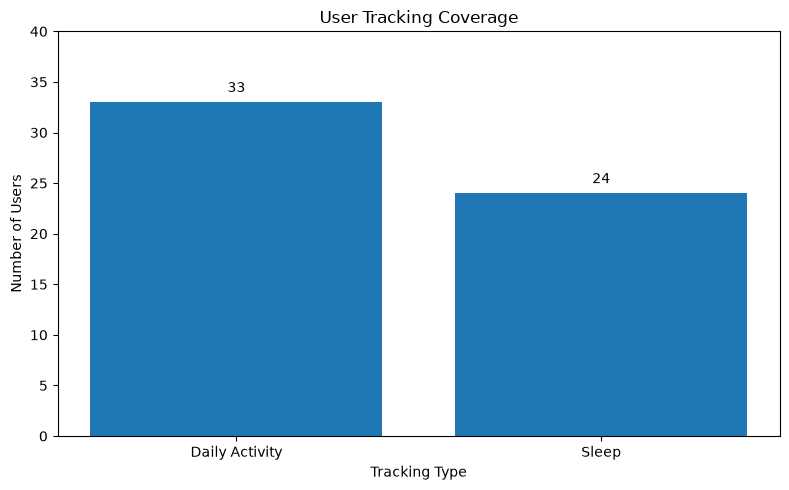

In [215]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    tracking_coverage["tracking_type"],
    tracking_coverage["users"]
)

plt.title("User Tracking Coverage")
plt.xlabel("Tracking Type")
plt.ylabel("Number of Users")
plt.ylim(0, 40)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.0f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(VISUALS_DIR / "user_tracking_coverage.png")

plt.show()

### User Tracking Coverage

This chart compares the number of users who tracked daily activity with the number of users who tracked sleep.

The daily activity dataset includes 33 users, while the sleep dataset includes 24 users.

This shows that sleep tracking has lower user coverage than daily activity tracking.

This insight is useful for Bellabeat because the company could encourage users to track sleep more consistently through reminders, onboarding messages, and sleep habit notifications.

query = """
SELECT
    activity_level,
    COUNT(*) AS records
FROM daily_activity
GROUP BY activity_level
ORDER BY records DESC;
"""

activity_distribution = pd.read_sql_query(query, conn)

activity_distribution

In [217]:
query = """
SELECT
    d.id,
    d.date,
    ROUND(d.sedentary_minutes / 60.0, 2) AS sedentary_hours,
    s.sleep_hours
FROM daily_activity d
INNER JOIN sleep s
    ON d.id = s.id
    AND d.date = s.date;
"""

sedentary_sleep = pd.read_sql_query(query, conn)

sedentary_sleep.head()

,id,date,sedentary_hours,sleep_hours
0,1503960366,2016-04-12,12.13,5.45
1,1503960366,2016-04-13,12.93,6.40
2,1503960366,2016-04-15,12.10,6.87
3,1503960366,2016-04-16,12.88,5.67
4,1503960366,2016-04-17,8.98,11.67


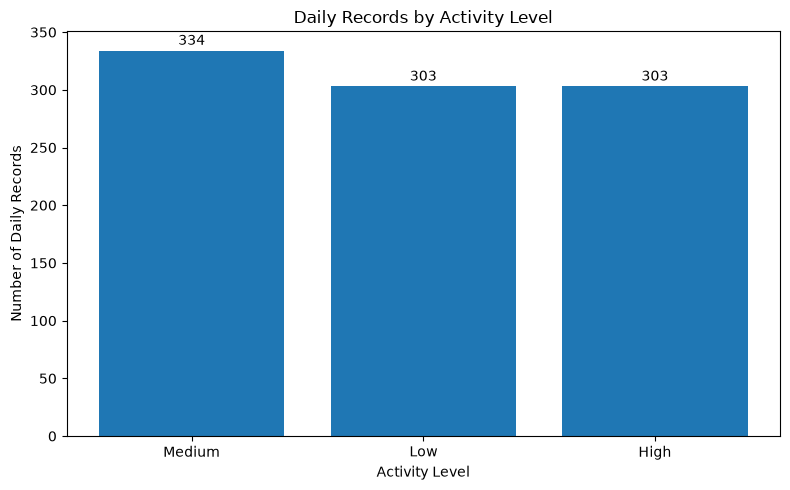

In [218]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    activity_distribution["activity_level"],
    activity_distribution["records"]
)

plt.title("Daily Records by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Number of Daily Records")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{height:.0f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(VISUALS_DIR / "daily_records_by_activity_level.png")

plt.show()

### Daily Records by Activity Level

This chart shows the number of daily records for each activity level.

It helps understand how the cleaned dataset is distributed across Low, Medium, and High activity days.

In [219]:
query = """
SELECT
    sedentary_level,
    COUNT(*) AS records,
    ROUND(AVG(sedentary_hours), 2) AS avg_sedentary_hours,
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours
FROM (
    SELECT
        d.id,
        d.date,
        ROUND(d.sedentary_minutes / 60.0, 2) AS sedentary_hours,
        s.sleep_hours,
        CASE
            WHEN d.sedentary_minutes < 600 THEN 'Low sedentary'
            WHEN d.sedentary_minutes < 800 THEN 'Medium sedentary'
            ELSE 'High sedentary'
        END AS sedentary_level
    FROM daily_activity d
    INNER JOIN sleep s
        ON d.id = s.id
        AND d.date = s.date
)
GROUP BY sedentary_level
ORDER BY avg_sedentary_hours;
"""

sleep_by_sedentary = pd.read_sql_query(query, conn)

sleep_by_sedentary

,sedentary_level,records,avg_sedentary_hours,avg_sleep_hours
0,Low sedentary,81,8.09,8.61
1,Medium sedentary,237,11.83,7.12
2,High sedentary,92,15.30,5.22


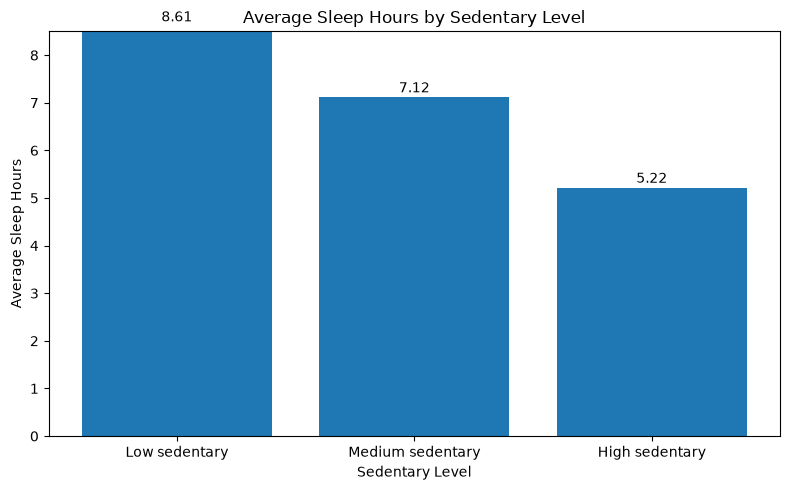

In [220]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    sleep_by_sedentary["sedentary_level"],
    sleep_by_sedentary["avg_sleep_hours"]
)

plt.title("Average Sleep Hours by Sedentary Level")
plt.xlabel("Sedentary Level")
plt.ylabel("Average Sleep Hours")
plt.ylim(0, 8.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(VISUALS_DIR / "avg_sleep_hours_by_sedentary_level.png")

plt.show()

### Average Sleep Hours by Sedentary Level

This chart compares average sleep hours across sedentary levels.

The goal is to understand whether users with higher sedentary time also show differences in sleep duration.

This visualization is useful for Bellabeat because sedentary behavior is something the app can act on through movement reminders, wellness notifications, and daily activity goals.

If higher sedentary levels are associated with lower sleep duration, Bellabeat could encourage users to take short movement breaks during the day.

In [221]:
query = """
SELECT
    d.id,
    d.date,
    ROUND(d.sedentary_minutes / 60.0, 2) AS sedentary_hours,
    s.sleep_hours
FROM daily_activity d
INNER JOIN sleep s
    ON d.id = s.id
    AND d.date = s.date;
"""

sedentary_sleep = pd.read_sql_query(query, conn)

sedentary_sleep.head()

,id,date,sedentary_hours,sleep_hours
0,1503960366,2016-04-12,12.13,5.45
1,1503960366,2016-04-13,12.93,6.40
2,1503960366,2016-04-15,12.10,6.87
3,1503960366,2016-04-16,12.88,5.67
4,1503960366,2016-04-17,8.98,11.67


In [222]:
correlation = sedentary_sleep["sedentary_hours"].corr(sedentary_sleep["sleep_hours"])
round(correlation, 2)

np.float64(-0.6)

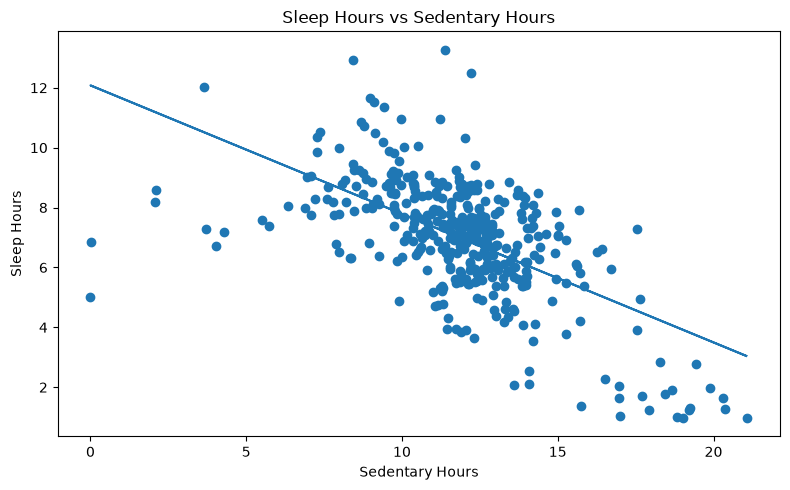

In [223]:
import numpy as np
import matplotlib.pyplot as plt

x = sedentary_sleep["sedentary_hours"]
y = sedentary_sleep["sleep_hours"]

# línea de tendencia
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 5))
plt.scatter(x, y)

plt.plot(x, m * x + b)

plt.title("Sleep Hours vs Sedentary Hours")
plt.xlabel("Sedentary Hours")
plt.ylabel("Sleep Hours")

plt.tight_layout()
plt.savefig(VISUALS_DIR / "sleep_hours_vs_sedentary_hours.png")
plt.show()

### Sleep Hours vs Sedentary Hours

This scatterplot shows the relationship between sedentary hours and sleep hours.

Each point represents one user on one day.

The correlation coefficient is -0.60, which suggests a moderate negative relationship between sedentary time and sleep duration.

As sedentary hours increase, sleep hours tend to decrease.

This insight is useful for Bellabeat because sedentary behavior can be addressed through movement reminders, activity nudges, and wellness notifications.

# Act Phase

In this phase, I provide business recommendations for Bellabeat based on the main findings from the analysis.

## Recommendations

### 1. Encourage more consistent sleep tracking

The daily activity dataset includes 33 users, while the sleep dataset includes 24 users.

This shows that sleep tracking has lower user coverage than daily activity tracking.

Bellabeat could encourage users to track sleep more consistently through reminders, onboarding messages, and sleep habit notifications.

### 2. Use sedentary-time alerts

The analysis showed that sedentary time is negatively related to sleep duration.

The correlation between sedentary hours and sleep hours was -0.60, which suggests a moderate negative relationship.

As sedentary hours increase, sleep hours tend to decrease.

Bellabeat could use movement reminders, inactivity alerts, and daily activity goals to help users reduce long sedentary periods.

### 3. Combine activity and sleep insights

Bellabeat could combine activity, sedentary behavior, and sleep data to provide more personalized wellness insights.

For example, the app could show users how their sedentary time and movement habits may relate to their sleep patterns.

## Limitations

This dataset is small and covers only one month.

The data comes from Fitbit users, not directly from Bellabeat users.

The analysis shows patterns and relationships, but it does not prove causation.

## Final Conclusion

The analysis showed that sleep tracking had lower user coverage than daily activity tracking.

It also showed that sedentary time was negatively related to sleep duration, with a correlation coefficient of -0.60.

Based on these findings, Bellabeat could improve its app experience by encouraging more consistent sleep tracking, sending movement reminders, and helping users understand how sedentary behavior relates to sleep.